In [8]:
import torch
from torch.utils.data import Dataset
from torch import nn
from torch.utils.data import DataLoader
from torch import optim

from soap import SOAP

In [9]:
class SyntheticLowRankDataset(Dataset):
    def __init__(self, dset_size: int, d_data: int, rank: int = 4) -> None:
        super().__init__()
        self.data = torch.randn(dset_size, d_data)
        # Generate a low-rank matrix: U (d_data x rank) @ V (rank x d_data)
        U = torch.randn(d_data, rank)
        V = torch.randn(rank, d_data)
        self.lowrank_matrix = U @ V  # shape (d_data, d_data)
        # Compute targets with low-rank linear projection + noise
        proj = (self.data @ self.lowrank_matrix)  # shape (dset_size, d_data)
        self.targets = proj + 0.5 * torch.randn_like(proj) # shape (dset_size, d_data)
        # Standardize targets
        self.targets -= torch.mean(self.targets)
        self.targets /= torch.std(self.targets)

    def __len__(self) -> int:
        return self.data.shape[0]

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.data[idx, :], self.targets[idx, :]

In [10]:
def get_all_weight_svd(model: torch.nn.Module) -> dict:
    """
    For each Linear layer in the model, compute and save the singular values
    of its weight matrix.

    Returns:
        dict: mapping from layer index to singular values (torch.Tensor)
    """
    sv_dict = {}
    layer_idx = 0
    for module in model.modules():
        if isinstance(module, torch.nn.Linear):
            W = module.weight.detach().cpu()
            if W.ndim == 1:
                W = W.unsqueeze(0)
            # Only compute SVD when matrix has valid size
            if min(W.shape) > 0:
                # full_matrices=False gives "economy" SVD
                _, S, _ = torch.linalg.svd(W, full_matrices=False)
                sv_dict[layer_idx] = S
            else:
                sv_dict[layer_idx] = None
            layer_idx += 1
    return sv_dict


In [11]:
d_data = 32
num_epochs = 500
dataset_size = 2000
batch_size = 200
hidden_dim = 64

model = nn.Sequential(nn.Linear(d_data, hidden_dim, bias=False), nn.ReLU(), nn.Linear(hidden_dim, d_data, bias=False))

loss = nn.MSELoss()

dataset = SyntheticLowRankDataset(dataset_size, d_data)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

data_np = dataset.data.numpy()
targets_np = dataset.targets.numpy()

In [15]:
#opt = optim.SGD(model.parameters(), lr=4e-1)
#opt = optim.Adam(model.parameters(), lr=1e-3)
#opt = optim.Muon(model.parameters(), lr=1e-2)
opt = SOAP(model.parameters(), lr=1e-2)

# Initialize model weights with better initialization
def init_weights(m):
    if isinstance(m, nn.Linear):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)

# Create a list to store SVDs at each iteration
all_svd_dicts = []
losses = []

for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_x, batch_y in dataloader:
        opt.zero_grad()
        preds = model(batch_x)
        l = loss(preds, batch_y)
        l.backward()
        opt.step()
        total_loss += l.item() * batch_x.size(0)
        # Compute and save SVD after each optimizer step
        svd_dict = get_all_weight_svd(model)
        all_svd_dicts.append(svd_dict)
    avg_loss = total_loss / len(dataset)
    losses.append(avg_loss)
    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")


Epoch 1/500, Loss: 1.2356
Epoch 50/500, Loss: 0.0020
Epoch 100/500, Loss: 0.0019
Epoch 150/500, Loss: 0.0019
Epoch 200/500, Loss: 0.0019
Epoch 250/500, Loss: 0.0019
Epoch 300/500, Loss: 0.0018
Epoch 350/500, Loss: 0.0018
Epoch 400/500, Loss: 0.0018
Epoch 450/500, Loss: 0.0018
Epoch 500/500, Loss: 0.0018


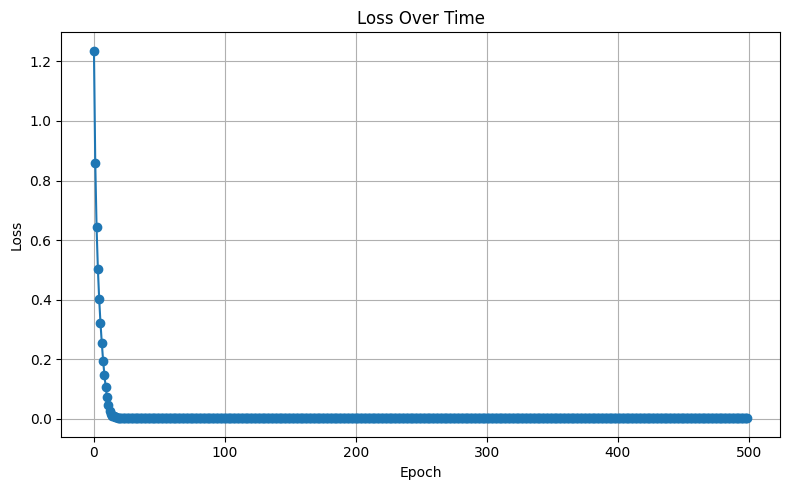

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()


/var/folders/_y/_by33x69401_4qlws_gy87sc0000gn/T/ipykernel_2681/376409325.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  singular_values_over_time = [np.array(s) for s in singular_values_over_time]


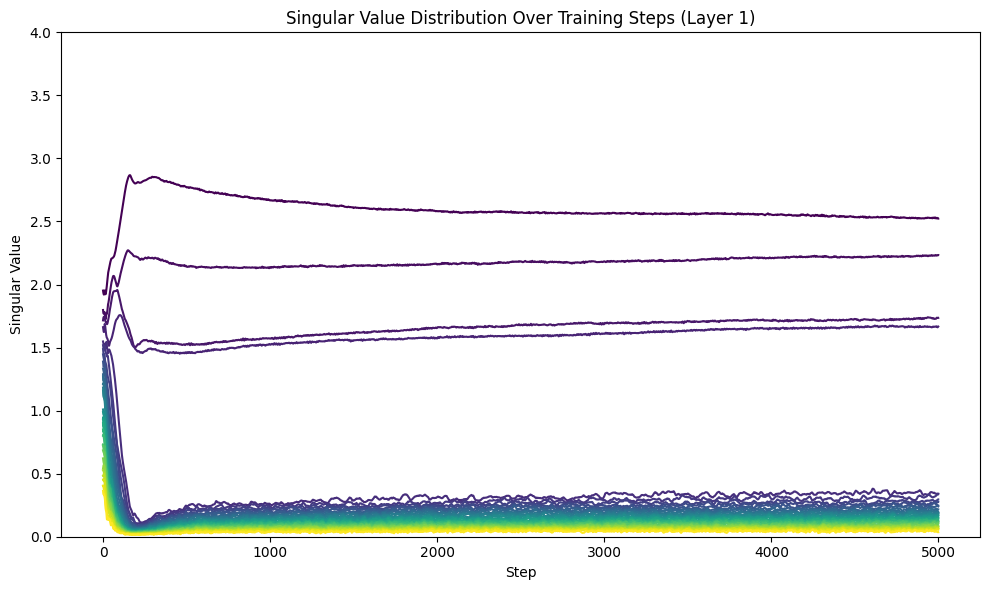

In [19]:
index = 1
min_sv = 0
max_sv = 4

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Collect singular value distributions for 'index' layer over time
singular_values_over_time = []

for svd_dict in all_svd_dicts:
    singular_val_dist = svd_dict[index]
    singular_values_over_time.append(singular_val_dist)

# Convert to numpy array for easier plotting (shape: [steps, num_singular_values])
singular_values_over_time = [np.array(s) for s in singular_values_over_time]
singular_values_over_time = np.stack(singular_values_over_time)

num_sv = singular_values_over_time.shape[1]
colors = cm.viridis(np.linspace(0, 1, num_sv))

plt.figure(figsize=(10, 6))
for i in range(num_sv):
    plt.plot(
        singular_values_over_time[:, i],
        label=f'Rank {i+1}' if num_sv < 10 else None,
        color=colors[i]
    )
plt.xlabel('Step')
plt.ylabel('Singular Value')
plt.title(f'Singular Value Distribution Over Training Steps (Layer {index})')
plt.ylim(min_sv, max_sv)
if num_sv < 10:
    plt.legend(title="Singular Value Rank")
plt.tight_layout()
plt.show()
